<a href="https://colab.research.google.com/github/5ahar-K/Project/blob/main/RMSE%2C%20defocused%2C%20AR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LINK PARAMETER SUMMARY
  wz              = 3.0908 cm
  Regime          = Gaussian (wz<ra)
  eta             = 99.466677 %  (-0.02 dB)
  delta (defocus) = 0.5000 mm
  sigma_I         = 0.5000 mm  (= 0.5 * wa)

Building Malaga CDF... done.

  L= 20  Pt= -25.0 dBm  RMSE=907.918 µm  P_int=0.2389 (geom=0.0000, snr=0.2389)
  L= 20  Pt= -20.0 dBm  RMSE=1114.083 µm  P_int=0.0698 (geom=0.0000, snr=0.0698)
  L= 20  Pt= -15.0 dBm  RMSE=1246.101 µm  P_int=0.0158 (geom=0.0000, snr=0.0158)
  L= 20  Pt= -10.0 dBm  RMSE=1309.925 µm  P_int=0.0047 (geom=0.0000, snr=0.0047)
  L= 20  Pt=  -5.0 dBm  RMSE=1337.205 µm  P_int=0.0010 (geom=0.0000, snr=0.0010)
  L= 20  Pt=   0.0 dBm  RMSE=1347.682 µm  P_int=0.0002 (geom=0.0000, snr=0.0002)
  L= 20  Pt=   5.0 dBm  RMSE=1350.005 µm  P_int=0.0002 (geom=0.0000, snr=0.0002)
  L= 20  Pt=  10.0 dBm  RMSE=1351.425 µm  P_int=0.0000 (geom=0.0000, snr=0.0000)
  L= 20  Pt=  15.0 dBm  RMSE=1351.649 µm  P_int=0.0000 (geom=0.0000, snr=0.0000)
  L= 20  Pt=  20.0 dBm  RMSE=1351

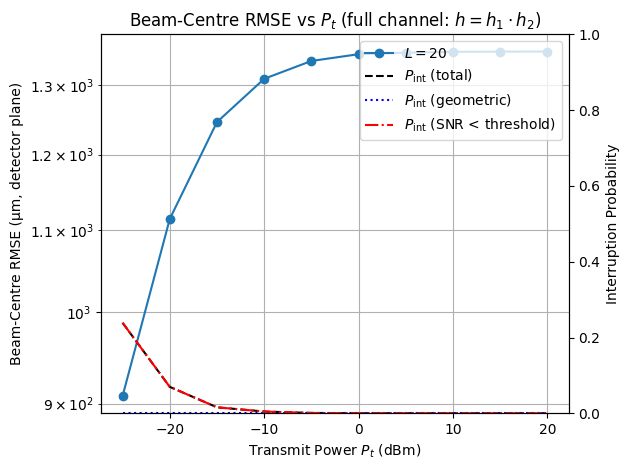

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math

# ======================
# Helper: Q-function
# ======================
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))


# ======================
# Link parameter calculation (defocusing)
# ======================
def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa):
    """
    Compute wz, eta, sigma_I from physical link parameters.
    sigma_I is set via defocusing: sigma_I = 0.5 * wa.
    """
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)

    sigma_I = 0.5 * wa                 # defocused spot size
    delta   = sigma_I * fc / ra        # required defocus distance

    print("=" * 55)
    print("LINK PARAMETER SUMMARY")
    print("=" * 55)
    print(f"  wz              = {wz*100:.4f} cm")
    print(f"  Regime          = {'Gaussian (wz<ra)' if wz < ra else 'Airy (wz>ra)'}")
    print(f"  eta             = {eta*100:.6f} %  ({10*np.log10(max(eta,1e-30)):.2f} dB)")
    print(f"  delta (defocus) = {delta*1e3:.4f} mm")
    print(f"  sigma_I         = {sigma_I*1e3:.4f} mm  (= 0.5 * wa)")
    print("=" * 55)
    print()
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I, "delta": delta}


# ======================
# h1 = h_ul * h_ua  (path loss × Malaga turbulence)
# ======================
def malaga_pdf(h, alpha, beta, g, Omega):
    """
    Málaga(M) irradiance PDF, Eq. (3) in the paper.
    beta must be a positive integer.
    """
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)

    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))

    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer for this Málaga PDF.")

    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)

    return AM * out


def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    """
    Build a numerical CDF grid for Málaga sampling.
    Call once and reuse across batches.
    """
    h_grid      = np.linspace(0.0, h_max, grid_n)
    h_grid[0]   = 1e-12
    pdf         = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf         = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf        /= cdf[-1]
    return h_grid, cdf


def sample_malaga_batch(h_grid, cdf, size, rng):
    """
    Fast inverse-CDF sampling using a prebuilt grid.
    Returns (size,) samples.
    """
    u = rng.random(size)
    return np.interp(u, cdf, h_grid)


def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    """
    h1 = h_ul * h_ua
    h_ul = exp(-zeta1 * Z)  (deterministic Beer-Lambert path loss)
    h_ua ~ Malaga           (turbulence fading)
    Returns (size,) array.
    """
    hul = np.exp(-zeta1 * Z)
    hua = sample_malaga_batch(h_grid, cdf, size, rng)
    return hul * hua


# ======================
# h2 = pointing error power fraction per pixel
# ======================
def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc, sigma_I):
    """
    theta_x, theta_y : (B,) AoA angles (rad)
    Returns h2 : (B, Na, Na) normalised power fraction per pixel.
    """
    w_prime  = wa + wf
    x0       = fc * theta_x   # (B,)
    y0       = fc * theta_y

    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1      = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2      = (x_right[None, :] - x0[:, None]) / sigma_I
    px       = Q(ax1) - Q(ax2)    # (B, Na)

    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1      = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2      = (y_top[None, :]    - y0[:, None]) / sigma_I
    py       = Q(ay1) - Q(ay2)    # (B, Na)

    h2 = px[:, :, None] * py[:, None, :]   # (B, Na, Na)

    s        = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]

    return h2


# ======================
# Interruption mask — geometric + SNR threshold
# ======================
def interruption_mask(theta_x, theta_y, Na, wa, wf, fc):
    """True where beam centre falls outside detector array (geometric only)."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc * theta_x)**2 + (fc * theta_y)**2)
    return r_d > r_array


def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    """
    True where instantaneous SNR falls below threshold.

    The total received power for a '1' symbol is:
        P_rx = eta * Pt * h1
    (h2 is normalised to sum to 1, so summing over all pixels
     gives total power = eta * Pt * h1)

    Instantaneous SNR (peak, all power collected):
        gamma = (mu * P_rx)^2 / (sigma_s^2 * P_rx + sigma0^2)

    Parameters
    ----------
    h1           : (B,) turbulence + path loss gain
    Pt           : transmit power (W)
    mu           : responsivity
    sigma_s      : shot noise scaling
    sigma0       : thermal/background noise std
    eta          : aperture capture fraction
    gamma_th_dB  : SNR threshold in dB (default 5 dB)

    Returns
    -------
    mask : (B,) boolean, True = SNR below threshold
    """
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1                          # (B,)
    mean_sq  = (mu * P_rx) ** 2
    var      = sigma_s**2 * P_rx + sigma0**2
    gamma    = mean_sq / var                          # (B,) instantaneous SNR
    return gamma < gamma_th


# ======================
# Received signal generation  — full channel h = h1 * h2
# ======================
def generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0, rng, eta=1.0, p1=0.5):
    """
    Generate received signal R incorporating the full channel h = h1 * h2.

    Parameters
    ----------
    Pt      : transmit power (W)
    h1      : (B,) path loss × turbulence gain per trial
    h2      : (B, Na, Na) normalised pointing-error pixel fractions
    L       : time slots per block
    mu      : detector responsivity
    sigma_s : shot noise scaling
    sigma0  : thermal/background noise std
    rng     : numpy Generator
    eta     : aperture capture fraction
    p1      : prob of transmitting '1'

    Returns
    -------
    s : (B, L)          transmitted symbols
    R : (B, Na, Na, L)  received signal per pixel per slot
    """
    B, Na, _ = h2.shape

    s = (rng.random((B, L)) < p1).astype(float)   # (B, L)

    # Full channel: scale h2 by h1 (turbulence + path loss)
    # h1 : (B,) → (B, 1, 1) for broadcasting
    h_full = h1[:, None, None] * h2                # (B, Na, Na)

    s4     = s[:, None, None, :]                   # (B, 1,  1,  L)
    h4     = h_full[:, :, :, None]                 # (B, Na, Na, 1)
    Pt_rx  = eta * Pt                              # received power after aperture loss

    mean = mu * Pt_rx * h4 * s4
    var  = (sigma_s**2) * (Pt_rx * h4 * s4) + sigma0**2

    R = rng.normal(mean, np.sqrt(var))
    return s, R


# ======================
# Joint detect+track
# ======================
def joint_track_h_hat_batch(R, mu):
    """
    R : (B, Na, Na, L)
    Returns h_hat : (B, Na, Na) estimated channel map.
    """
    B, Na, _, L = R.shape

    y        = np.sum(R, axis=(1, 2))              # (B, L)
    order    = np.argsort(-y, axis=1)              # (B, L)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)

    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))    # (B, L)
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1       # (B,)

    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)

    s4         = s_hat_sorted[:, None, None, :]
    R_weighted = R_sorted * s4
    h_hat      = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)

    return h_hat


# ======================
# Beam centre estimation
# ======================
def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    """
    Weighted centroid of h_hat to estimate beam centre.
    Returns x_hat, y_hat : (B,) in metres.
    """
    w_prime = wa + wf
    B       = h_hat.shape[0]

    x_c = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c = (np.arange(Na) - (Na - 1) / 2.0) * w_prime

    h_pos = np.maximum(h_hat, 0.0)
    total = np.sum(h_pos, axis=(1, 2))

    hx    = np.sum(h_pos, axis=2)    # (B, Na) marginal over y
    hy    = np.sum(h_pos, axis=1)    # (B, Na) marginal over x

    safe  = total > 0
    x_hat = np.zeros(B)
    y_hat = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]

    return x_hat, y_hat


# ======================
# RMSE for one Pt value — full channel h = h1 * h2
# ======================
def rmse_for_Pt(Pt, params, h1_cdf, n_trials, rng,
                batch_size=5000, interrupted_penalty=None):
    """
    Parameters
    ----------
    Pt          : transmit power (W)
    params      : simulation parameter dict
    h1_cdf      : (h_grid, cdf) tuple from build_malaga_cdf — prebuilt once
    n_trials    : Monte Carlo trials
    rng         : numpy Generator
    batch_size  : trials per batch
    interrupted_penalty : None or float

    Returns
    -------
    rmse, int_frac
    """
    Na           = params["Na"]
    wa           = params["wa"]
    wf           = params["wf"]
    fc           = params["fc"]
    sigma_I      = params["sigma_I"]
    L            = params["L"]
    mu           = params["mu"]
    sigma_s      = params["sigma_s"]
    sigma0       = params["sigma0"]
    eta          = params.get("eta", 1.0)
    Z            = params["Z"]
    zeta1        = params["zeta1"]
    gamma_th_dB  = params.get("gamma_th_dB", 5.0)   # SNR threshold (dB)

    h_grid, cdf = h1_cdf

    sq_err_sum = 0.0
    n_valid    = 0
    n_int_geom = 0   # geometric interruptions (beam misses array)
    n_int_snr  = 0   # SNR interruptions (channel too weak)

    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)

        theta_x = rng.normal(0.0, params["sigma_x"], size=B)
        theta_y = rng.normal(0.0, params["sigma_y"], size=B)

        x_true = fc * theta_x
        y_true = fc * theta_y

        # --- Geometric interruption: beam misses array ---
        geom_int = interruption_mask(theta_x, theta_y, Na, wa, wf, fc)
        n_int_geom += int(np.sum(geom_int))

        # --- Draw h1 for ALL trials (needed for SNR check) ---
        h1_all = sample_h1_batch(Z, zeta1, h_grid, cdf, size=B, rng=rng)

        # --- SNR interruption: channel too weak (only for non-geometric) ---
        snr_int = np.zeros(B, dtype=bool)
        non_geom = ~geom_int
        if np.any(non_geom):
            snr_int[non_geom] = snr_mask(
                h1_all[non_geom], Pt, mu, sigma_s, sigma0, eta, gamma_th_dB
            )
        n_int_snr += int(np.sum(snr_int))

        # --- Combined interruption ---
        interrupted = geom_int | snr_int
        n_int_total  = int(np.sum(interrupted))

        if interrupted_penalty is not None:
            sq_err_sum += n_int_total * (interrupted_penalty ** 2)
            n_valid    += n_int_total

        # --- Non-interrupted trials: run full tracking ---
        keep = ~interrupted
        if np.any(keep):
            B2 = int(np.sum(keep))
            tx = theta_x[keep]
            ty = theta_y[keep]
            xt = x_true[keep]
            yt = y_true[keep]
            h1 = h1_all[keep]

            # h2: pointing error pixel fractions
            h2 = compute_h2_batch(tx, ty, Na, wa, wf, fc, sigma_I)

            # Full channel combined in generate_R_batch
            _, R  = generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0,
                                     rng, eta=eta)
            h_hat = joint_track_h_hat_batch(R, mu)

            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)

            sq_err_sum += np.sum((x_hat - xt)**2 + (y_hat - yt)**2)
            n_valid    += B2

        done += B

    n_int_total = n_int_geom + n_int_snr
    rmse      = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac  = n_int_total / n_trials
    int_frac_geom = n_int_geom / n_trials
    int_frac_snr  = n_int_snr  / n_trials
    return rmse, int_frac, int_frac_geom, int_frac_snr


# ======================
# RMSE plot for multiple L values
# ======================
def plot_rmse_vs_Pt_for_L_list(base_params, h1_cdf, L_list,
                               Pt_list, Pt_dBm_list,
                               n_trials=100_000, seed=1234,
                               batch_size=5000,
                               interrupted_penalty=None):
    rng = np.random.default_rng(seed)

    fig, ax1 = plt.subplots()
    int_fracs_last      = []
    int_fracs_geom_last = []
    int_fracs_snr_last  = []

    for L in L_list:
        params = base_params.copy()
        params["L"] = L

        rmse_vals       = []
        int_fracs       = []
        int_fracs_geom  = []
        int_fracs_snr   = []

        for Pt in Pt_list:
            rmse, int_frac, int_frac_geom, int_frac_snr = rmse_for_Pt(
                Pt, params, h1_cdf, n_trials, rng,
                batch_size=batch_size,
                interrupted_penalty=interrupted_penalty
            )
            rmse_vals.append(rmse * 1e6)
            int_fracs.append(int_frac)
            int_fracs_geom.append(int_frac_geom)
            int_fracs_snr.append(int_frac_snr)
            print(f"  L={L:3d}  Pt={10*np.log10(Pt)+30:6.1f} dBm  "
                  f"RMSE={rmse*1e6:.3f} µm  "
                  f"P_int={int_frac:.4f} "
                  f"(geom={int_frac_geom:.4f}, snr={int_frac_snr:.4f})")

        int_fracs_last      = int_fracs
        int_fracs_geom_last = int_fracs_geom
        int_fracs_snr_last  = int_fracs_snr
        ax1.semilogy(Pt_dBm_list, rmse_vals, marker="o", label=rf"$L={L}$")

    ax1.set_xlabel("Transmit Power $P_t$ (dBm)")
    ax1.set_ylabel("Beam-Centre RMSE (µm, detector plane)")
    ax1.set_title("Beam-Centre RMSE vs $P_t$ (full channel: $h = h_1 \\cdot h_2$)")
    ax1.grid(True, which="both")

    ax2 = ax1.twinx()
    ax2.plot(Pt_dBm_list, int_fracs_last,      "k--",  linewidth=1.5,
             label=r"$P_\mathrm{int}$ (total)")
    ax2.plot(Pt_dBm_list, int_fracs_geom_last, "b:",   linewidth=1.5,
             label=r"$P_\mathrm{int}$ (geometric)")
    ax2.plot(Pt_dBm_list, int_fracs_snr_last,  "r-.",  linewidth=1.5,
             label=r"$P_\mathrm{int}$ (SNR < threshold)")
    ax2.set_ylabel("Interruption Probability")
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()


# ======================
# Power sweep helper
# ======================
def make_power_sweep(Pt_dB_min=-55, Pt_dB_max=-10, n_points=20):
    Pt_dB_list  = np.linspace(Pt_dB_min, Pt_dB_max, n_points)
    Pt_list     = 10 ** (Pt_dB_list / 10.0)
    Pt_dBm_list = Pt_dB_list + 30
    return Pt_list, Pt_dBm_list


# ======================
# Run
# ======================
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Physical link parameters
    # ------------------------------------------------------------------
    lam   = 1550e-9    # wavelength (m)
    Z     = 250        # link distance (m)
    Cn2   = 1.7e-13    # turbulence strength (m^-2/3)
    w0    = 0.03       # transmit beam waist woz (m)
    fc    = 0.05       # receiver focal length (m)
    ra    = 0.05       # receiver aperture radius (m)
    Na    = 4         # pixels per side (use 16 for final run)
    wa    = 1e-3       # pixel width (m)

    # ------------------------------------------------------------------
    # Malaga turbulence parameters (from paper Table I / Table IV)
    # Strong turbulence defaults from paper
    # ------------------------------------------------------------------
    rho   = 0.596
    Omega_prime = 1.3265
    b0    = 0.1079
    g     = 2 * b0 * (1 - rho)
    Omega = Omega_prime
    alpha = 2.296    # from Rytov variance at Z=250m, Cn2=1.7e-13
    beta  = 2        # must be integer

    zeta1 = 0.43e-3  # atmospheric attenuation coefficient (m^-1)
                     # e.g. 0.43 dB/km = 0.43e-3 Np/m for clear air

    # ------------------------------------------------------------------
    # Compute wz, eta, sigma_I from link physics + defocusing
    # ------------------------------------------------------------------
    link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa)

    # ------------------------------------------------------------------
    # Build Malaga CDF once — reused across all Pt values and batches
    # ------------------------------------------------------------------
    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.")
    print()

    # ------------------------------------------------------------------
    # Simulation parameters
    # ------------------------------------------------------------------
    base_params = {
        "Na"          : Na,
        "wa"          : wa,
        "wf"          : 0.0,
        "fc"          : fc,
        "sigma_I"     : link["sigma_I"],
        "eta"         : link["eta"],
        "sigma_x"     : 4e-3,
        "sigma_y"     : 4e-3,
        "mu"          : 1.0,
        "sigma_s"     : 2e-5,
        "sigma0"      : 6.3e-7,
        "L"           : 20,
        "Z"           : Z,
        "zeta1"       : zeta1,
        "gamma_th_dB" : 5.0,    # SNR threshold (dB) — interruption if below this
    }

    r_array = (Na * wa) / 2.0
    interrupted_penalty = None
    # interrupted_penalty = r_array

    # ------------------------------------------------------------------
    # Quick run flag — set False for final accurate results
    # ------------------------------------------------------------------
    QUICK = True
    if QUICK:
        n_trials   = 20_000
        n_points   = 10
        L_list     = [20]
        batch_size = 10_000
    else:
        n_trials   = 200_000
        n_points   = 20
        L_list     = [10, 20]
        batch_size = 10_000

    Pt_list, Pt_dBm_list = make_power_sweep(-55, -10, n_points)

    plot_rmse_vs_Pt_for_L_list(
        base_params         = base_params,
        h1_cdf              = (h_grid, cdf),
        L_list              = L_list,
        Pt_list             = Pt_list,
        Pt_dBm_list         = Pt_dBm_list,
        n_trials            = n_trials,
        seed                = 1234,
        batch_size          = batch_size,
        interrupted_penalty = interrupted_penalty,
    )

AR(1) CORRELATION PARAMETERS
  data_rate         = 1000.0 Mbps
  t_slot/Tc_theta   = 0.100 
  Tc_theta          = 0.0 ms
  t_slot/Tc_h1  = 0.000 
  Tc_h1             = 2.0 ms
  rho_theta         = 0.904837
  rho_h1            = 1.000000
  Interpretation:
    rho_theta~1 -> frozen jitter  (Tc_theta >> t_slot)
    rho_theta~0 -> i.i.d. jitter  (Tc_theta << t_slot)

LINK PARAMETER SUMMARY
  wz                = 3.0908 cm
  Regime            = Gaussian (wz<ra)
  eta               = 99.466677 %  (-0.02 dB)
  delta (defocus)   = 3.0000 mm
  fc                = 50.00 mm
  fc_eff = fc+delta = 53.0000 mm
  delta/fc          = 6.00 %
  sigma_I           = 3.0000 mm
  sigma_I/wa        = 3.00

Building Malaga CDF... done.

  L=  5  Pt= -25.0 dBm  RMSE=556.2412 um  P_int=0.6234
  L=  5  Pt= -16.7 dBm  RMSE=473.0930 um  P_int=0.1094
  L=  5  Pt=  -8.3 dBm  RMSE=371.0439 um  P_int=0.0110
  L=  5  Pt=   0.0 dBm  RMSE=340.2801 um  P_int=0.0022
  L=  5  Pt=   8.3 dBm  RMSE=340.0976 um  P_int=0.0000
  L=

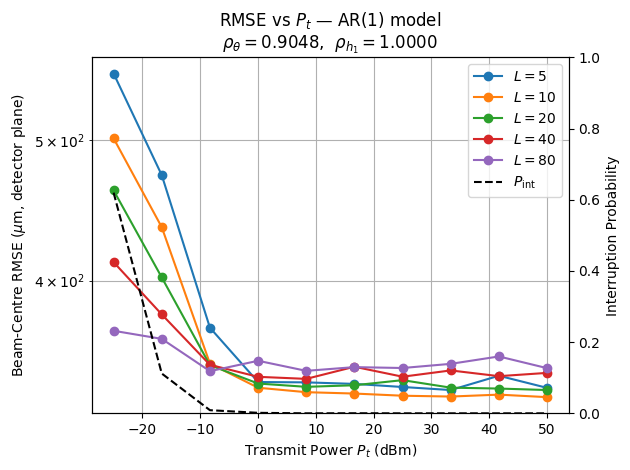

  L=   5  RMSE=339.3635 um  P_int=0.0002
  L=  10  RMSE=332.5073 um  P_int=0.0002
  L=  20  RMSE=337.1977 um  P_int=0.0000
  L=  40  RMSE=348.1004 um  P_int=0.0000
  L=  80  RMSE=349.2066 um  P_int=0.0000


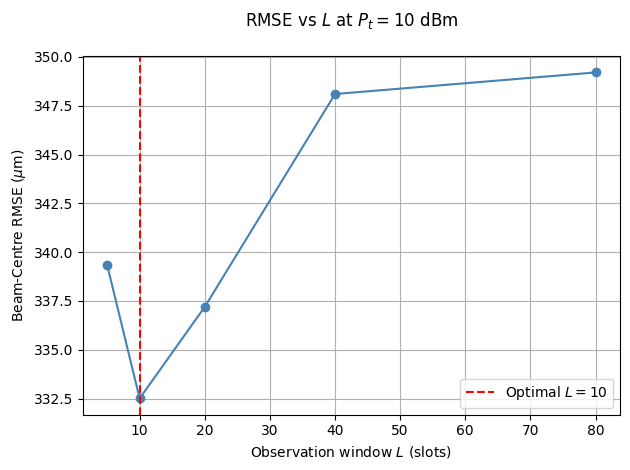


Optimal L = 10  (RMSE = 332.5073 um)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math

# ======================
# Helper: Q-function
# ======================
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))


# ======================
# Link parameter calculation (defocusing)
# ======================
def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa):
    """
    Compute wz, eta, sigma_I, delta, fc_eff from physical link parameters.

    sigma_I = 3*wa  (defocused spot spans ~3 pixels for good centroiding).
    fc_eff  = fc + delta  (exact ray-trace spot centre: x0 = fc_eff * theta).
    """
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)
    sigma_I = 3 * wa
    delta   = sigma_I * fc / ra
    fc_eff  = fc + delta
    print("=" * 55)
    print("LINK PARAMETER SUMMARY")
    print("=" * 55)
    print(f"  wz                = {wz*100:.4f} cm")
    print(f"  Regime            = {'Gaussian (wz<ra)' if wz < ra else 'Airy (wz>ra)'}")
    print(f"  eta               = {eta*100:.6f} %  ({10*np.log10(max(eta,1e-30)):.2f} dB)")
    print(f"  delta (defocus)   = {delta*1e3:.4f} mm")
    print(f"  fc                = {fc*1e3:.2f} mm")
    print(f"  fc_eff = fc+delta = {fc_eff*1e3:.4f} mm")
    print(f"  delta/fc          = {delta/fc*100:.2f} %")
    print(f"  sigma_I           = {sigma_I*1e3:.4f} mm")
    print(f"  sigma_I/wa        = {sigma_I/wa:.2f}")
    print("=" * 55)
    print()
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I,
            "delta": delta, "fc_eff": fc_eff}


# ======================
# AR(1) utilities
# ======================
def ar1_coefficient(Tc, data_rate):
    """
    Compute AR(1) coefficient from coherence time and slot duration.

    Model:  theta[l] = rho * theta[l-1] + sigma_w * w[l],  w ~ N(0,1)
    Autocorrelation: R(k*t_slot) = sigma^2 * rho^k = sigma^2 * exp(-k*t_slot/Tc)

    So rho = exp(-t_slot / Tc).

    Parameters
    ----------
    Tc     : coherence time (s)
             - UAV body jitter:    Tc ~ 5-50 ms
             - Rotor vibration:    Tc ~ 1-5 ms
             - Atm. turbulence:    Tc ~ 1-10 ms
    t_slot : slot duration = 1 / data_rate (s)

    Returns
    -------
    rho : AR(1) coefficient
          rho -> 1 : nearly frozen  (Tc >> t_slot)
          rho -> 0 : nearly i.i.d. (Tc << t_slot)
    """

    return float(np.exp(-1/(data_rate*Tc)))

def ar1_noise_std(sigma, rho):
    """
    Driving noise std to maintain stationary variance sigma^2.
    sigma_w = sigma * sqrt(1 - rho^2)
    """
    return sigma * np.sqrt(1.0 - rho**2)


def generate_ar1_block(B, L, sigma, rho, rng):
    """
    Generate AR(1) sequences for a batch of B trials, each L slots long.

    theta[0]   ~ N(0, sigma^2)            stationary initial state
    theta[l]   = rho * theta[l-1] + sigma_w * w[l]

    Parameters
    ----------
    B     : batch size
    L     : slots per block
    sigma : stationary std of process (rad for AoA, dimensionless for h1 log)
    rho   : AR(1) coefficient

    Returns
    -------
    seq : (B, L)
    """
    sigma_w = ar1_noise_std(sigma, rho)
    seq     = np.zeros((B, L))
    seq[:, 0] = rng.normal(0.0, sigma, size=B)
    for l in range(1, L):
        seq[:, l] = rho * seq[:, l-1] + sigma_w * rng.normal(0.0, 1.0, size=B)
    return seq


# ======================
# h1 = h_ul * h_ua  (path loss x Malaga turbulence)
# ======================
def malaga_pdf(h, alpha, beta, g, Omega):
    """
    Malaga(M) irradiance PDF. beta must be a positive integer.
    """
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)
    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))
    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer.")
    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)
    return AM * out


def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    """Build numerical CDF once — reused across all batches and slots."""
    h_grid    = np.linspace(0.0, h_max, grid_n)
    h_grid[0] = 1e-12
    pdf       = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf       = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf      /= cdf[-1]
    return h_grid, cdf


def sample_malaga_batch(h_grid, cdf, size, rng):
    return np.interp(rng.random(size), cdf, h_grid)


def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    """h1 = exp(-zeta1*Z) * h_ua,   h_ua ~ Malaga."""
    return np.exp(-zeta1 * Z) * sample_malaga_batch(h_grid, cdf, size, rng)


def generate_h1_ar1_block(B, L, Z, zeta1, h_grid, cdf, rho_h1, rng):
    """
    Generate correlated h1 sequences using AR(1) in the log domain.

    Physical basis: log-amplitude of optical turbulence is approximately
    Gaussian (Rytov theory), so AR(1) in log domain is natural.

    log(h_ua)[l] = rho_h1 * log(h_ua)[l-1] + sigma_w_h1 * w[l]

    Initial h_ua[0] drawn from Malaga CDF (correct marginal distribution).
    Subsequent values are AR(1) correlated in log domain.

    Parameters
    ----------
    rho_h1 : AR(1) coefficient for turbulence
             = exp(-t_slot / Tc_turbulence)

    Returns
    -------
    h1_seq : (B, L)
    """
    hul = np.exp(-zeta1 * Z)

    # Initial draw from correct Malaga marginal
    hua_0    = sample_malaga_batch(h_grid, cdf, size=B, rng=rng)
    log_hua  = np.log(np.maximum(hua_0, 1e-300))

    # Estimate stationary log-std from initial draw
    # (use a large sample to get stable estimate; here use the batch itself)
    sigma_log = float(np.std(log_hua))
    if sigma_log < 1e-10:
        sigma_log = 1.0   # fallback for degenerate case
    sigma_w_h1 = ar1_noise_std(sigma_log, rho_h1)

    h1_seq       = np.zeros((B, L))
    h1_seq[:, 0] = hul * hua_0

    for l in range(1, L):
        log_hua      = rho_h1 * log_hua + \
                       sigma_w_h1 * rng.normal(0.0, 1.0, size=B)
        h1_seq[:, l] = hul * np.exp(log_hua)

    return h1_seq


# ======================
# h2 = pointing-error pixel power fractions
# ======================
def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc_eff, sigma_I):
    """
    theta_x, theta_y : (B,)
    Spot centre: x0 = fc_eff * theta  (defocus-corrected).
    Returns h2 : (B, Na, Na) normalised.
    """
    w_prime  = wa + wf
    x0       = fc_eff * theta_x
    y0       = fc_eff * theta_y
    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1 = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2 = (x_right[None, :] - x0[:, None]) / sigma_I
    px  = Q(ax1) - Q(ax2)
    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1 = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2 = (y_top[None, :]    - y0[:, None]) / sigma_I
    py  = Q(ay1) - Q(ay2)
    h2  = px[:, :, None] * py[:, None, :]
    s   = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]
    return h2


# ======================
# Interruption masks
# ======================
def interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff):
    """Geometric: beam centre outside array."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc_eff * theta_x)**2 + (fc_eff * theta_y)**2)
    return r_d > r_array


def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    """
    SNR below threshold.
    Total power at detector = eta * Pt * h1  (since h2 sums to 1).
    gamma = (mu * eta * Pt * h1)^2 / (sigma_s^2 * eta * Pt * h1 + sigma0^2)
    """
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1
    gamma    = (mu * P_rx)**2 / (sigma_s**2 * P_rx + sigma0**2)
    return gamma < gamma_th


# ======================
# AR(1) block signal generation
# ======================
def generate_R_ar1_batch(Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
                          mu, sigma_s, sigma0, rng,
                          Z, zeta1, h_grid, cdf,
                          sigma_x, sigma_y,
                          rho_theta, rho_h1,
                          eta=1.0, p1=0.5):
    """
    Generate received signal block with AR(1) correlated channel.

    AoA process:
        theta_x[l] = rho_theta * theta_x[l-1] + sigma_w_theta * wx[l]
        theta_y[l] = rho_theta * theta_y[l-1] + sigma_w_theta * wy[l]
        (x and y are independent AR(1) processes with same rho_theta)

    Turbulence process:
        log(h_ua[l]) = rho_h1 * log(h_ua[l-1]) + sigma_w_h1 * wh[l]

    True position = beam centre at LAST slot (slot L-1).
        x_true = fc_eff * theta_x[L-1]
        y_true = fc_eff * theta_y[L-1]

    This is the physically correct definition for real-time stationkeeping:
    the algorithm estimates where the beam IS NOW at end of block,
    which is what the UAV needs to correct its pointing.

    Interruption: block is interrupted if the LAST slot is interrupted
    (geometric or SNR). This is consistent with x_true = last slot.

    Parameters
    ----------
    rho_theta : AR(1) coeff for AoA = exp(-t_slot / Tc_jitter)
    rho_h1    : AR(1) coeff for h1  = exp(-t_slot / Tc_turbulence)

    Returns
    -------
    R        : (B, Na, Na, L)
    x_true   : (B,) true beam centre x at last slot
    y_true   : (B,) true beam centre y at last slot
    last_int : (B,) bool — True if last slot is interrupted
    """
    # --- Generate correlated sequences for all slots ---
    theta_x_seq = generate_ar1_block(B, L, sigma_x, rho_theta, rng)  # (B, L)
    theta_y_seq = generate_ar1_block(B, L, sigma_y, rho_theta, rng)  # (B, L)
    h1_seq      = generate_h1_ar1_block(B, L, Z, zeta1,
                                         h_grid, cdf, rho_h1, rng)   # (B, L)

    R = np.zeros((B, Na, Na, L))

    for l in range(L):
        theta_x_l = theta_x_seq[:, l]
        theta_y_l = theta_y_seq[:, l]
        h1_l      = h1_seq[:, l]

        h2_l     = compute_h2_batch(theta_x_l, theta_y_l,
                                     Na, wa, wf, fc_eff, sigma_I)
        h_full_l = h1_l[:, None, None] * h2_l   # (B, Na, Na)

        s_l   = (rng.random(B) < p1).astype(float)
        s3    = s_l[:, None, None]
        Pt_rx = eta * Pt
        mean_l = mu * Pt_rx * h_full_l * s3
        var_l  = sigma_s**2 * (Pt_rx * h_full_l * s3) + sigma0**2
        R[:, :, :, l] = rng.normal(mean_l, np.sqrt(var_l))

    # --- True position = LAST slot ---
    x_true = fc_eff * theta_x_seq[:, L-1]
    y_true = fc_eff * theta_y_seq[:, L-1]

    # --- Interruption = last slot interrupted ---
    last_geom = interruption_mask(theta_x_seq[:, L-1],
                                   theta_y_seq[:, L-1],
                                   Na, wa, wf, fc_eff)
    last_snr  = snr_mask(h1_seq[:, L-1], Pt, mu, sigma_s, sigma0, eta)
    last_int  = last_geom | last_snr

    return R, x_true, y_true, last_int


# ======================
# Joint detect+track
# ======================
def joint_track_h_hat_batch(R, mu):
    """R : (B, Na, Na, L) -> h_hat : (B, Na, Na)"""
    B, Na, _, L = R.shape
    y        = np.sum(R, axis=(1, 2))
    order    = np.argsort(-y, axis=1)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)
    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1
    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)
    s4           = s_hat_sorted[:, None, None, :]
    R_weighted   = R_sorted * s4
    h_hat        = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)
    return h_hat


# ======================
# Beam centre estimation
# ======================
def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    """
    Weighted centroid -> x_hat, y_hat (B,) in detector-plane metres.
    AoA:          theta_hat = x_hat / fc_eff
    Displacement: d_hat     = x_hat * Z / fc_eff
    """
    w_prime = wa + wf
    B       = h_hat.shape[0]
    x_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    h_pos   = np.maximum(h_hat, 0.0)
    total   = np.sum(h_pos, axis=(1, 2))
    hx      = np.sum(h_pos, axis=2)
    hy      = np.sum(h_pos, axis=1)
    safe    = total > 0
    x_hat   = np.zeros(B)
    y_hat   = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]
    return x_hat, y_hat


# ======================
# RMSE for one Pt value
# ======================
def rmse_for_Pt(Pt, params, h1_cdf, n_trials, rng,
                batch_size=1000, interrupted_penalty=None):
    """
    AR(1) correlated channel model.
    True position  = beam centre at last slot.
    Interruption   = last slot geometrically or SNR-interrupted.
    """
    Na          = params["Na"]
    wa          = params["wa"]
    wf          = params["wf"]
    fc_eff      = params["fc_eff"]
    sigma_I     = params["sigma_I"]
    L           = params["L"]
    mu          = params["mu"]
    sigma_s     = params["sigma_s"]
    sigma0      = params["sigma0"]
    eta         = params.get("eta", 1.0)
    Z           = params["Z"]
    zeta1       = params["zeta1"]
    sigma_x     = params["sigma_x"]
    sigma_y     = params["sigma_y"]
    rho_theta   = params["rho_theta"]
    rho_h1      = params["rho_h1"]

    h_grid, cdf = h1_cdf
    sq_err_sum  = 0.0
    n_valid     = 0
    n_int       = 0

    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)

        R, x_true, y_true, last_int = generate_R_ar1_batch(
            Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
            mu, sigma_s, sigma0, rng,
            Z, zeta1, h_grid, cdf,
            sigma_x, sigma_y,
            rho_theta, rho_h1,
            eta=eta
        )

        n_int += int(np.sum(last_int))

        if interrupted_penalty is not None:
            n_int_b     = int(np.sum(last_int))
            sq_err_sum += n_int_b * (interrupted_penalty ** 2)
            n_valid    += n_int_b

        keep = ~last_int
        if np.any(keep):
            B2           = int(np.sum(keep))
            h_hat        = joint_track_h_hat_batch(R[keep], mu)
            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)
            sq_err_sum  += np.sum((x_hat - x_true[keep])**2 +
                                   (y_hat - y_true[keep])**2)
            n_valid     += B2

        done += B

    rmse     = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac = n_int / n_trials
    return rmse, int_frac


# ======================
# RMSE plot for multiple L values
# ======================
def plot_rmse_vs_Pt_for_L_list(base_params, h1_cdf, L_list,
                               Pt_list, Pt_dBm_list,
                               n_trials=50_000, seed=1234,
                               batch_size=1000,
                               interrupted_penalty=None):
    rng = np.random.default_rng(seed)
    fig, ax1 = plt.subplots()
    int_fracs_last = []

    for L in L_list:
        params = base_params.copy()
        params["L"] = L
        rmse_vals = []
        int_fracs = []

        for Pt in Pt_list:
            rmse, int_frac = rmse_for_Pt(
                Pt, params, h1_cdf, n_trials, rng,
                batch_size=batch_size,
                interrupted_penalty=interrupted_penalty
            )
            rmse_vals.append(rmse * 1e6)
            int_fracs.append(int_frac)
            print(f"  L={L:3d}  Pt={10*np.log10(Pt)+30:6.1f} dBm  "
                  f"RMSE={rmse*1e6:.4f} um  P_int={int_frac:.4f}")

        int_fracs_last = int_fracs
        ax1.semilogy(Pt_dBm_list, rmse_vals, marker="o", label=rf"$L={L}$")

    rho_t = base_params["rho_theta"]
    rho_h = base_params["rho_h1"]
    ax1.set_xlabel("Transmit Power $P_t$ (dBm)")
    ax1.set_ylabel("Beam-Centre RMSE ($\\mu$m, detector plane)")
    ax1.set_title(f"RMSE vs $P_t$ — AR(1) model\n"
                  f"$\\rho_\\theta={rho_t:.4f}$,  "
                  f"$\\rho_{{h_1}}={rho_h:.4f}$")
    ax1.grid(True, which="both")

    ax2 = ax1.twinx()
    ax2.plot(Pt_dBm_list, int_fracs_last, "k--", linewidth=1.5,
             label=r"$P_\mathrm{int}$")
    ax2.set_ylabel("Interruption Probability")
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()


# ======================
# RMSE vs L plot at fixed Pt
# Shows the U-shaped curve and reveals optimal L
# ======================
def plot_rmse_vs_L(base_params, h1_cdf, L_list, Pt_fixed_dBm,
                   n_trials=50_000, seed=1234, batch_size=1000):
    """
    Plot RMSE vs L at a fixed Pt to reveal the optimal observation window.
    The U-shape shows: small L = noise limited, large L = dynamics limited.
    """
    rng    = np.random.default_rng(seed)
    Pt     = 10 ** ((Pt_fixed_dBm - 30) / 10.0)
    rmse_vals = []
    int_fracs = []

    for L in L_list:
        params = base_params.copy()
        params["L"] = L
        rmse, int_frac = rmse_for_Pt(
            Pt, params, h1_cdf, n_trials, rng,
            batch_size=batch_size
        )
        rmse_vals.append(rmse * 1e6)
        int_fracs.append(int_frac)
        print(f"  L={L:4d}  RMSE={rmse*1e6:.4f} um  P_int={int_frac:.4f}")

    fig, ax1 = plt.subplots()
    ax1.plot(L_list, rmse_vals, marker="o", color="steelblue")
    ax1.set_xlabel("Observation window $L$ (slots)")
    ax1.set_ylabel("Beam-Centre RMSE ($\\mu$m)")
    ax1.set_title(f"RMSE vs $L$ at $P_t={Pt_fixed_dBm}$ dBm\n")
    ax1.grid(True)

    # Mark optimal L
    idx_opt = int(np.argmin(rmse_vals))
    ax1.axvline(L_list[idx_opt], color="red", linestyle="--", linewidth=1.5,
                label=f"Optimal $L={L_list[idx_opt]}$")
    ax1.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal L = {L_list[idx_opt]}  "
          f"(RMSE = {rmse_vals[idx_opt]:.4f} um)")


# ======================
# Power sweep helper
# ======================
def make_power_sweep(Pt_dB_min=-55, Pt_dB_max=20, n_points=20):
    Pt_dB_list  = np.linspace(Pt_dB_min, Pt_dB_max, n_points)
    Pt_list     = 10 ** (Pt_dB_list / 10.0)
    Pt_dBm_list = Pt_dB_list + 30
    return Pt_list, Pt_dBm_list


# ======================
# Run
# ======================
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # PARAMETER GUIDE
    # ------------------------------------------------------------------
    #
    # NEW PARAMETERS vs previous frozen-channel code:
    #
    # data_rate   (bps)
    #   The OOK symbol rate. Sets the slot duration t_slot = 1/data_rate.
    #   Typical FSO: 1 Mbps to 1 Gbps.
    #   Higher data_rate -> shorter t_slot -> more slots fit within coherence
    #   time -> rho closer to 1 -> channel more correlated between slots.
    #
    # Tc_theta   (s)
    #   Coherence time of the UAV AoA jitter process.
    #   = time over which the beam pointing angle is strongly correlated.
    #   Slow body drift:     Tc_theta ~ 50-200 ms
    #   Moderate body sway:  Tc_theta ~ 5-50 ms
    #   Rotor vibration:     Tc_theta ~ 1-5 ms
    #   Set from UAV IMU data or published vibration spectra.
    #   If unknown, use Tc_theta = 10 ms as a conservative default.
    #
    # Tc_h1      (s)
    #   Coherence time of the atmospheric turbulence channel h1.
    #   = time over which the turbulence fading is strongly correlated.
    #   Typical FSO at 250m:  Tc_h1 ~ 1-10 ms
    #   Stronger wind -> shorter Tc_h1.
    #   Set from Rytov variance and wind speed, or use Tc_h1 ~ 2 ms default.
    #
    # rho_theta = exp(-t_slot / Tc_theta)
    #   AR(1) coefficient for AoA process. Computed automatically.
    #   rho_theta -> 1 : nearly frozen (Tc_theta >> t_slot)
    #   rho_theta -> 0 : nearly i.i.d.(Tc_theta << t_slot)
    #
    # rho_h1    = exp(-t_slot / Tc_h1)
    #   AR(1) coefficient for turbulence h1. Computed automatically.
    #   Same interpretation as rho_theta.
    #
    # The two special limiting cases:
    #   rho_theta=0, rho_h1=0  -> per-slot i.i.d. model
    #   rho_theta=1, rho_h1=1  -> frozen channel model
    #
    # True position = beam centre at LAST slot of block.
    #   This is the correct definition for real-time stationkeeping:
    #   the UAV needs to know where the beam is NOW (end of block)
    #   to correct its pointing for the next block.
    #
    # Interruption = last slot is geometrically or SNR-interrupted.
    #   Consistent with true position definition.
    #
    # ------------------------------------------------------------------

    # Physical link parameters
    lam = 1550e-9    # wavelength (m)
    Z   = 250        # link distance (m)
    Cn2 = 1.7e-13    # turbulence strength (m^-2/3)
    w0  = 0.03       # transmit beam waist (m)
    fc  = 0.05       # focal length (m)
    ra  = 0.05       # aperture radius (m)
    Na  = 4          # pixels per side
    wa  = 1e-3       # pixel width (m)

    # Malaga turbulence parameters
    rho_M       = 0.596
    Omega_prime = 1.3265
    b0          = 0.1079
    g           = 2 * b0 * (1 - rho_M)
    Omega       = Omega_prime
    alpha       = 2.296
    beta        = 2           # must be integer
    zeta1       = 0.43e-3     # attenuation coefficient (m^-1)

    # ------------------------------------------------------------------
    # AR(1) parameters — SET THESE FOR YOUR SYSTEM
    # ------------------------------------------------------------------
    data_rate = 1e9    # symbol rate (bps) — sets t_slot


    Tc_theta  = 10e-9  # AoA jitter coherence time (s)
                         # 10 ms = moderate UAV body sway
                         # Increase for slower UAV, decrease for faster

    Tc_h1     = 2e-3 # turbulence coherence time (s)
                         # 2 ms = moderate turbulence at 250m
                         # Decrease for stronger wind / longer path

    rho_theta = ar1_coefficient(Tc_theta, data_rate)
    rho_h1    = ar1_coefficient(Tc_h1,    data_rate)

    print("=" * 55)
    print("AR(1) CORRELATION PARAMETERS")
    print("=" * 55)
    print(f"  data_rate         = {data_rate/1e6:.1f} Mbps")
    print(f"  t_slot/Tc_theta   = {(1/(data_rate*Tc_theta)):.3f} ")
    print(f"  Tc_theta          = {Tc_theta*1e3:.1f} ms")
    print(f"  t_slot/Tc_h1  = {(1/(data_rate*Tc_h1)):.3f} ")
    print(f"  Tc_h1             = {Tc_h1*1e3:.1f} ms")
    print(f"  rho_theta         = {rho_theta:.6f}")
    print(f"  rho_h1            = {rho_h1:.6f}")
    print(f"  Interpretation:")
    print(f"    rho_theta~1 -> frozen jitter  (Tc_theta >> t_slot)")
    print(f"    rho_theta~0 -> i.i.d. jitter  (Tc_theta << t_slot)")
    print("=" * 55)
    print()

    # Compute link params
    link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa)

    # Build Malaga CDF once
    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.\n")

    # Simulation parameters
    base_params = {
        "Na"         : Na,
        "wa"         : wa,
        "wf"         : 0.0,
        "fc_eff"     : link["fc_eff"],
        "sigma_I"    : link["sigma_I"],
        "eta"        : link["eta"],
        "sigma_x"    : 4e-3,          # UAV jitter std (rad)
        "sigma_y"    : 4e-3,
        "mu"         : 1.0,           # detector responsivity (A/W)
        "sigma_s"    : 2e-5,          # shot noise scaling
        "sigma0"     : 2e-6,          # thermal + background noise std
        "L"          : 20,            # placeholder — overridden by L_list
        "Z"          : Z,
        "zeta1"      : zeta1,
        "gamma_th_dB": 5.0,
        # --- NEW AR(1) parameters ---
        "rho_theta"  : rho_theta,     # AR(1) coeff for AoA jitter
        "rho_h1"     : rho_h1,        # AR(1) coeff for turbulence h1
    }

    r_array             = (Na * wa) / 2.0
    interrupted_penalty = None

    QUICK = True
    if QUICK:
        n_trials   = 5_000
        n_points   = 10
        L_list     = [5, 10, 20, 40, 80]
        batch_size = 500
    else:
        n_trials   = 50_000
        n_points   = 20
        L_list     = [5, 10, 20, 40, 80]
        batch_size = 500

    Pt_list, Pt_dBm_list = make_power_sweep(-55, 20, n_points)

    # Plot 1: RMSE vs Pt for multiple L
    plot_rmse_vs_Pt_for_L_list(
        base_params         = base_params,
        h1_cdf              = (h_grid, cdf),
        L_list              = L_list,
        Pt_list             = Pt_list,
        Pt_dBm_list         = Pt_dBm_list,
        n_trials            = n_trials,
        seed                = 1234,
        batch_size          = batch_size,
        interrupted_penalty = interrupted_penalty,
    )

    # Plot 2: RMSE vs L at fixed high Pt — reveals optimal L (U-shape)
    plot_rmse_vs_L(
        base_params    = base_params,
        h1_cdf         = (h_grid, cdf),
        L_list         = L_list,
        Pt_fixed_dBm   = 10,       # high SNR so noise floor is visible
        n_trials       = n_trials,
        seed           = 5678,
        batch_size     = batch_size,
    )